**MK Rekayasa Fitur**

**Topik:** Seleksi Fitur
- **Dataset**: Data Tabular

**Galih Hermawan. Prodi Teknik Informatika. UNIKOM**

---

# Kasus 1.
Menentukan apakah rata-rata nilai akhir berbeda secara signifikan di antara berbagai indeks atau huruf mutu.

In [1]:
import pandas as pd
import scipy.stats as stats

# Memuat data
data = pd.read_csv('data_mahasiswa_baru.csv')

# Menampilkan beberapa baris data untuk memeriksa
data.head()


,nim,nama,mata_kuliah,semester,tahun_pengambilan,kehadiran,nilai_tugas,nilai_uts,nilai_uas,nilai_akhir,indeks
0,180001,Budi Santoso,Pemrograman Berorientasi Objek,4,2022,14,85,78,82,74.6,B
1,180001,Budi Santoso,Rekayasa Perangkat Lunak,6,2023,15,85,88,90,80.9,A
2,180001,Budi Santoso,Bahasa Inggris,3,2022,14,80,82,85,76.0,B
3,180001,Budi Santoso,Pemrograman Web,5,2023,15,85,88,90,80.9,A
4,180001,Budi Santoso,Pengantar Informatika,1,2021,16,90,85,88,80.3,A


In [2]:
# Melihat nilai unik dari kolom 'indeks'
data['indeks'].unique()

array(['B', 'A', 'E', 'D', 'C'], dtype=object)

In [3]:
data.groupby('indeks')['nilai_akhir'].describe()

,count,mean,std,min,25%,50%,75%,max
indeks,,,,,,,,
A,27.0,81.366667,0.967948,80.3,80.300,80.90,82.400,82.4
B,66.0,76.087879,2.684286,71.0,74.600,76.00,78.175,79.2
C,11.0,67.554545,2.685280,61.2,67.650,69.00,69.000,69.0
D,4.0,49.100000,4.760952,46.1,46.100,47.10,50.100,56.1
E,2.0,11.450000,15.768481,0.3,5.875,11.45,17.025,22.6


In [4]:
# Mengelompokkan nilai_akhir berdasarkan indeks
# Perhatikan penggunaan [['nilai_akhir', 'indeks']] untuk memilih DUA kolom
groups_with_indeks = [data[data['indeks'] == category][['nilai_akhir', 'indeks']] for category in data['indeks'].unique()]
groups_with_indeks

[     nilai_akhir indeks
 0           74.6      B
 2           76.0      B
 5           76.0      B
 8           76.0      B
 11          76.0      B
 ..           ...    ...
 101         71.0      B
 102         77.8      B
 105         79.2      B
 106         79.2      B
 108         79.2      B
 
 [66 rows x 2 columns],
      nilai_akhir indeks
 1           80.9      A
 3           80.9      A
 4           80.3      A
 6           80.3      A
 7           80.9      A
 9           80.3      A
 10          80.9      A
 12          82.4      A
 13          82.4      A
 14          82.4      A
 15          82.4      A
 24          80.3      A
 25          80.3      A
 26          80.3      A
 27          80.3      A
 50          82.4      A
 51          82.4      A
 52          82.4      A
 71          82.4      A
 72          82.4      A
 73          82.4      A
 74          80.9      A
 75          80.9      A
 76          80.3      A
 79          82.4      A
 86          80.3      A

In [5]:
# Mengelompokkan nilai_akhir berdasarkan indeks
groups = [data[data['indeks'] == category]['nilai_akhir'] for category in data['indeks'].unique()]

# Melakukan ANOVA
f_value, p_value = stats.f_oneway(*groups)

print(f"F-value: {f_value}")
print(f"p-value: {p_value}")

F-value: 372.23904562544067
p-value: 4.805733912561448e-61


In [6]:
# Menginterpretasi hasil
alpha = 0.05
if p_value < alpha:
    print("Ada perbedaan signifikan antara rata-rata nilai_akhir pada kelompok indeks yang berbeda.")
else:
    print("Tidak ada perbedaan signifikan antara rata-rata nilai_akhir pada kelompok indeks yang berbeda.")

Ada perbedaan signifikan antara rata-rata nilai_akhir pada kelompok indeks yang berbeda.


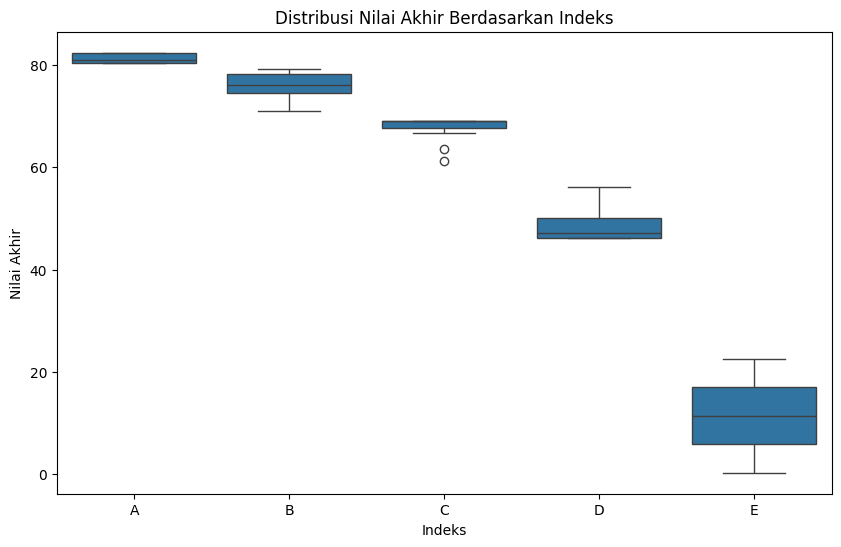

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat urutan indeks
order = ['A', 'B', 'C', 'D', 'E']

# Membuat box plot dengan urutan yang diinginkan
plt.figure(figsize=(10, 6))
sns.boxplot(x='indeks', y='nilai_akhir', data=data, order=order)
plt.title('Distribusi Nilai Akhir Berdasarkan Indeks')
plt.xlabel('Indeks')
plt.ylabel('Nilai Akhir')
plt.show()


---
# Kasus 2.
Mengevaluasi apakah ada perbedaan signifikan dalam nilai akhir (fitur kontinu) di antara berbagai mata kuliah (variabel kategorikal). Dalam hal ini, kita ingin melihat apakah rata-rata nilai akhir berbeda secara signifikan antara mata kuliah yang berbeda.

In [8]:
import pandas as pd
import scipy.stats as stats

# Memuat data
data = pd.read_csv('data_mahasiswa_baru.csv')

# Melihat beberapa baris data untuk memeriksa
#print(data.head())

# Mengelompokkan nilai_akhir berdasarkan mata_kuliah
groups = [data[data['mata_kuliah'] == course]['nilai_akhir'] for course in data['mata_kuliah'].unique()]
#print(groups)

# Melakukan ANOVA
f_value, p_value = stats.f_oneway(*groups)

print(f"F-value: {f_value}")
print(f"p-value: {p_value}")

# Menginterpretasi hasil
alpha = 0.05
if p_value < alpha:
    print("Ada perbedaan signifikan antara rata-rata nilai_akhir pada berbagai mata kuliah.")
else:
    print("Tidak ada perbedaan signifikan antara rata-rata nilai_akhir pada berbagai mata kuliah.")


F-value: 0.8191599846996249
p-value: 0.6792096251077353
Tidak ada perbedaan signifikan antara rata-rata nilai_akhir pada berbagai mata kuliah.


---
# Kasus 3.


In [9]:
import pandas as pd
import numpy as np

# Memuat data mahasiswa
data = pd.read_csv('data_mahasiswa_baru.csv')

# Menghitung korelasi Pearson antara jumlah kehadiran dan nilai akhir
corr = np.corrcoef(data['kehadiran'], data['nilai_akhir'])[0, 1]

print("Koefisien Korelasi Pearson:", corr)


Koefisien Korelasi Pearson: 0.9245032328054547


**Analisis Korelasi Pearson**
Koefisien korelasi Pearson dihitung untuk mengetahui hubungan linear antara jumlah kehadiran dan nilai akhir mahasiswa.
Hasil perhitungan menunjukkan nilai 0.92, yang berarti terdapat korelasi positif sangat kuat antara kehadiran dan nilai akhir — semakin sering hadir, cenderung semakin tinggi nilai akhirnya.